In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import StepLR
import matplotlib.pyplot as plt

seed = 42
torch.manual_seed(seed)

D_i, D_k, D_o = 10, 40, 5

num_samples = 100
batch_size = 10
num_epochs = 100
lr = 0.1
momentum = 0.9
step_size = 10
gamma = 0.5

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

X = torch.randn(num_samples, D_i)
Y = torch.randn(num_samples, D_o)

dataset = TensorDataset(X, Y)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

model = nn.Sequential(
    nn.Linear(D_i, D_k),
    nn.ReLU(),
    nn.Linear(D_k, D_k),
    nn.ReLU(),
    nn.Linear(D_k, D_o),
).to(device)

def weights_init(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

model.apply(weights_init)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)
scheduler = StepLR(optimizer, step_size=step_size, gamma=gamma)

print(model)

Using device: cpu
Sequential(
  (0): Linear(in_features=10, out_features=40, bias=True)
  (1): ReLU()
  (2): Linear(in_features=40, out_features=40, bias=True)
  (3): ReLU()
  (4): Linear(in_features=40, out_features=5, bias=True)
)
Sequential(
  (0): Linear(in_features=10, out_features=40, bias=True)
  (1): ReLU()
  (2): Linear(in_features=40, out_features=40, bias=True)
  (3): ReLU()
  (4): Linear(in_features=40, out_features=5, bias=True)
)


Epoch   1 | Loss: 1.8995 | LR: 0.10000
Epoch  10 | Loss: 0.6916 | LR: 0.05000
Epoch  10 | Loss: 0.6916 | LR: 0.05000
Epoch  20 | Loss: 0.4326 | LR: 0.02500
Epoch  20 | Loss: 0.4326 | LR: 0.02500
Epoch  30 | Loss: 0.3810 | LR: 0.01250
Epoch  30 | Loss: 0.3810 | LR: 0.01250
Epoch  40 | Loss: 0.3624 | LR: 0.00625
Epoch  40 | Loss: 0.3624 | LR: 0.00625
Epoch  50 | Loss: 0.3534 | LR: 0.00313
Epoch  50 | Loss: 0.3534 | LR: 0.00313
Epoch  60 | Loss: 0.3494 | LR: 0.00156
Epoch  60 | Loss: 0.3494 | LR: 0.00156
Epoch  70 | Loss: 0.3478 | LR: 0.00078
Epoch  70 | Loss: 0.3478 | LR: 0.00078
Epoch  80 | Loss: 0.3470 | LR: 0.00039
Epoch  80 | Loss: 0.3470 | LR: 0.00039
Epoch  90 | Loss: 0.3465 | LR: 0.00020
Epoch  90 | Loss: 0.3465 | LR: 0.00020
Epoch 100 | Loss: 0.3463 | LR: 0.00010
Epoch 100 | Loss: 0.3463 | LR: 0.00010


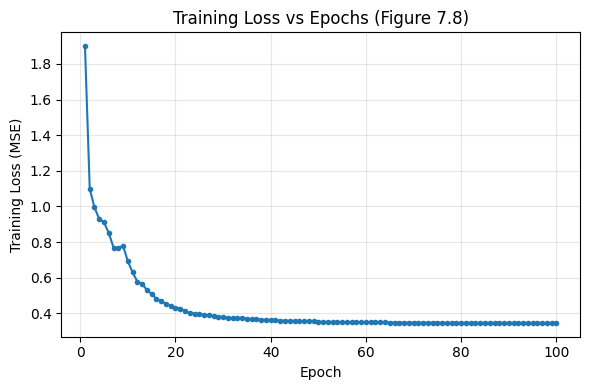

In [ ]:
loss_history = []

for epoch in range(1, num_epochs + 1):
    epoch_loss = 0.0
    model.train()
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * xb.size(0)

    epoch_loss /= num_samples
    loss_history.append(epoch_loss)

    scheduler.step()

    if epoch % 10 == 0 or epoch == 1:
        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch:3d} | Loss: {epoch_loss:.4f} | LR: {current_lr:.5f}')

plt.figure(figsize=(6,4))
plt.plot(range(1, num_epochs + 1), loss_history, marker='o', markersize=3)
plt.xlabel('Epoch')
plt.ylabel('Training Loss (MSE)')
plt.title('Training Loss vs Epochs (Figure 7.8)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()